# 🏺 Tourasna — Sequence Translation (Stage 3)
# Seq2Seq Transformer: Gardiner Codes → English/Arabic
# Dataset: BBAW Egyptian Corpus
# Repo: github.com/Tourasna/Tourasna

In [1]:
# ── Cell 2: Load BBAW dataset from HuggingFace ───────
!pip install datasets -q

from datasets import load_dataset

ds = load_dataset("phiwi/bbaw_egyptian")
print(ds)
print(f"\nColumn names: {ds['train'].column_names}")
print(f"\nFirst 3 examples:")
for i in range(3):
    print(f"\n--- Example {i+1} ---")
    for key in ds['train'].column_names:
        val = ds['train'][i][key]
        if val:
            print(f"  {key}: {str(val)[:200]}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/9.75M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100736 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['transcription', 'translation', 'hieroglyphs'],
        num_rows: 100736
    })
})

Column names: ['transcription', 'translation', 'hieroglyphs']

First 3 examples:

--- Example 1 ---
  transcription: ⸢pḏ,wt-9⸣   n =f   [⸮ḥtr?]   ⸢m⸣  
  translation: ... die Neun-Bogenvölker ... zu ihm ... Pferdegespann ...

--- Example 2 ---
  transcription: ḥtr tp,j ꜥꜣ n ḥm =f Ꜥꜣ-nḫt,w
  translation: [Pferde]: Das erste große Pfergespann seiner Majestät (namens) 'Groß an Siegen'.

--- Example 3 ---
  transcription: ⸢wr⸣.pl ⸢ꜥꜣi̯⸣.pl n.w ⸢Rṯn,w⸣ ⸢jni̯⸣ ⸢ḥm⸣ ⸢=f⸣ ⸢m⸣ ⸢sqr-ꜥnḫ⸣
  translation: [Gefangene]: Die großen Oberhäupter von Retjenu, die seine Majestät als Kriegsgefangene gebracht hat.


In [2]:
# ── Cell 3: Inspect the hieroglyphs column ────────────
print("=== Checking 'hieroglyphs' column ===")
for i in range(5):
    h = ds['train'][i]['hieroglyphs']
    print(f"\nExample {i+1}:")
    print(f"  hieroglyphs: {h}")
    print(f"  type: {type(h)}")
    print(f"  translation: {ds['train'][i]['translation'][:100]}")

=== Checking 'hieroglyphs' column ===

Example 1:
  hieroglyphs: 
  type: <class 'str'>
  translation: ... die Neun-Bogenvölker ... zu ihm ... Pferdegespann ...

Example 2:
  hieroglyphs: 
  type: <class 'str'>
  translation: [Pferde]: Das erste große Pfergespann seiner Majestät (namens) 'Groß an Siegen'.

Example 3:
  hieroglyphs: 
  type: <class 'str'>
  translation: [Gefangene]: Die großen Oberhäupter von Retjenu, die seine Majestät als Kriegsgefangene gebracht hat

Example 4:
  hieroglyphs: 
  type: <class 'str'>
  translation: Worte sprechen durch Isis, die Große, die Gottesmutter:

Example 5:
  hieroglyphs: 
  type: <class 'str'>
  translation: "Mein geliebter Sohn Ramses-meriamun, deine Lebenszeit ist wie (die) meines Sohnes Horus.


In [3]:
# ── Cell 4: Check hieroglyphs encoding ────────────────
for i in range(10):
    h = ds['train'][i]['hieroglyphs']
    if h and len(h.strip()) > 0:
        print(f"Example {i+1}:")
        print(f"  length: {len(h)}")
        print(f"  repr: {repr(h[:100])}")
        print(f"  codepoints: {[hex(ord(c)) for c in h[:20]]}")
        print()

# Also check how many rows actually have hieroglyphs
has_hieroglyphs = sum(1 for row in ds['train'] if row['hieroglyphs'] and len(row['hieroglyphs'].strip()) > 0)
print(f"\nRows with hieroglyphs: {has_hieroglyphs} / {len(ds['train'])}")


Rows with hieroglyphs: 35503 / 100736


In [4]:
# ── Cell 5: See actual hieroglyph data ────────────────
count = 0
for i in range(len(ds['train'])):
    h = ds['train'][i]['hieroglyphs']
    if h and len(h.strip()) > 0:
        print(f"Example {count+1}:")
        print(f"  hieroglyphs: {repr(h[:150])}")
        print(f"  codepoints:  {[hex(ord(c)) for c in h[:15]]}")
        print(f"  transcription: {ds['train'][i]['transcription'][:100]}")
        print(f"  translation: {ds['train'][i]['translation'][:100]}")
        print()
        count += 1
        if count >= 5:
            break

Example 1:
  hieroglyphs: 'D21 :Q3 :D36 F4 :D36 L2 -X1 :S19 S29 -U23 -T21 :X1 G17 -D21 :Z1 -R8 -U36 -S4 -F29 -X1 :X1 -B1 -V30 :X1 -U23 -D58 -G43 -N25 :O49 M17 -U1 -F39&Aa1 -M17 '
  codepoints:  ['0x44', '0x32', '0x31', '0x20', '0x3a', '0x51', '0x33', '0x20', '0x3a', '0x44', '0x33', '0x36', '0x20', '0x46', '0x34']
  transcription: jr,j-pꜥ,t ḥꜣ,tj-ꜥ ḫtm,w-bj,tj smr-wꜥ,tj jm,j-rʾ-ḥm(,pl)-nṯr-n-Stj,t-nb,t-Ꜣb,w jmꜣḫ,y-ḫr-Jnp,w Zꜣ-rnp
  translation: Hereditary noble and prince, royal seal-bearer and sole friend (of the king), overseer of the priest

Example 2:
  hieroglyphs: 'M17 -[? *A26 *?] S34 -/ :Aa1 -G43 -A1 -[? *Z3 *?] h/ :N17 :[? *N23 *?] -A1 -[? *Z2B *?] S29 -V4 -X1 S29 -N35 D2 *Z1 M17 -M40 -O34 :O1 *Z1 Q3 :N35 G17 '
  codepoints:  ['0x4d', '0x31', '0x37', '0x20', '0x2d', '0x5b', '0x3f', '0x20', '0x2a', '0x41', '0x32', '0x36', '0x20', '0x2a', '0x3f']
  transcription: j ꜥnḫ.w[.pl] [tp,j].pl-tꜣ swꜣ.t(j) =sn ḥr jz pn m-ḫdi̯ m ḫsfi̯.t m mri̯ ṯn nṯr.pl =ṯn jw =ṯn 〈r〉 dwꜣ
  translation: O 

In [5]:
# ── Cell 6: Full dataset analysis ─────────────────────
import re
from collections import Counter

# Filter rows that have both hieroglyphs and translation
valid_rows = []
for row in ds['train']:
    h = row['hieroglyphs']
    t = row['translation']
    if h and len(h.strip()) > 0 and t and len(t.strip()) > 0:
        valid_rows.append({'hieroglyphs': h.strip(), 'translation': t.strip()})

print(f"Valid parallel rows: {len(valid_rows)}")

# Extract pure Gardiner codes (remove layout operators)
def extract_codes(hieroglyph_str):
    """Extract just the Gardiner codes, removing layout operators and annotations"""
    # Remove annotations like [? *X *?], h/, */, \\
    clean = re.sub(r'\[.*?\]', '', hieroglyph_str)
    clean = re.sub(r'[h\*]/|\\\\', '', clean)
    # Split and keep only valid Gardiner codes (letter(s) + number(s))
    tokens = clean.split()
    codes = [t.strip('-:*') for t in tokens]
    codes = [c for c in codes if re.match(r'^[A-Z][a-z]?\d+[A-Za-z]?$', c)]
    return codes

# Analyze
all_codes = []
seq_lengths = []
for row in valid_rows:
    codes = extract_codes(row['hieroglyphs'])
    all_codes.extend(codes)
    seq_lengths.append(len(codes))

code_counts = Counter(all_codes)

print(f"\nTotal Gardiner codes extracted: {len(all_codes)}")
print(f"Unique codes: {len(code_counts)}")
print(f"\nSequence length stats:")
print(f"  Mean:   {sum(seq_lengths)/len(seq_lengths):.1f}")
print(f"  Median: {sorted(seq_lengths)[len(seq_lengths)//2]}")
print(f"  Max:    {max(seq_lengths)}")
print(f"  Min:    {min(seq_lengths)}")

print(f"\nTop 20 most common codes:")
for code, count in code_counts.most_common(20):
    print(f"  {code:8s} → {count:5d}")

# Check language distribution
german_count = sum(1 for r in valid_rows if any(w in r['translation'].lower() for w in ['der', 'die', 'das', 'und', 'von']))
english_count = sum(1 for r in valid_rows if any(w in r['translation'].lower() for w in ['the', 'and', 'of', 'his', 'who']))
print(f"\nLanguage estimate:")
print(f"  Likely German:  {german_count}")
print(f"  Likely English: {english_count}")

Valid parallel rows: 35501

Total Gardiner codes extracted: 731706
Unique codes: 1843

Sequence length stats:
  Mean:   20.6
  Median: 15
  Max:    718
  Min:    0

Top 20 most common codes:
  X1       → 61590
  N35      → 49420
  D21      → 34756
  M17      → 34158
  Z1       → 33329
  G17      → 22896
  Z7       → 22590
  Z2       → 20262
  I9       → 19926
  S29      → 17058
  D36      → 14774
  G1       → 13555
  Y1       → 11971
  Aa1      → 10490
  G7       →  9520
  A1       →  9405
  V28      →  9113
  Q3       →  8782
  G43      →  8302
  N5       →  7690

Language estimate:
  Likely German:  22942
  Likely English: 7201


In [6]:
# ── Cell 7: Filter English rows + check TLA dataset ──

# ── Part A: Filter English-only from BBAW ─────────────
import string

def is_english(text):
    """Simple heuristic: mostly ASCII + common English words"""
    ascii_ratio = sum(1 for c in text if c in string.printable) / max(len(text), 1)
    has_english = any(w in text.lower().split() for w in ['the', 'of', 'and', 'his', 'to', 'in', 'is', 'who', 'was'])
    has_german = any(w in text.lower().split() for w in ['der', 'die', 'das', 'und', 'des', 'dem', 'ein', 'ist', 'von'])
    return ascii_ratio > 0.85 and has_english and not has_german

english_rows = [r for r in valid_rows if is_english(r['translation'])]
print(f"English-only rows from BBAW: {len(english_rows)}")

# Show samples
for i in range(3):
    codes = extract_codes(english_rows[i]['hieroglyphs'])
    print(f"\nExample {i+1}:")
    print(f"  Codes ({len(codes)}): {' '.join(codes[:15])}...")
    print(f"  Translation: {english_rows[i]['translation'][:150]}")

# ── Part B: Load TLA dataset ──────────────────────────
print("\n\n=== Loading TLA dataset ===")
tla = load_dataset("thesaurus-linguae-aegyptiae/tla-Earlier_Egyptian_original-v18-premium")
print(tla)
print(f"\nColumns: {tla['train'].column_names}")
print(f"\nFirst 3 examples:")
for i in range(3):
    print(f"\n--- TLA Example {i+1} ---")
    for key in tla['train'].column_names:
        val = tla['train'][i][key]
        if val:
            print(f"  {key}: {str(val)[:200]}")

English-only rows from BBAW: 3338

Example 1:
  Codes (51): D21 Q3 D36 F4 D36 L2 X1 S19 S29 U23 T21 X1 G17 D21 Z1...
  Translation: Hereditary noble and prince, royal seal-bearer and sole friend (of the king), overseer of the priests of Satet, Mistress of Elephantine, one distingui

Example 2:
  Codes (66): M17 S34 Aa1 G43 A1 N17 A1 S29 V4 X1 S29 N35 D2 Z1 M17...
  Translation: O living ones, who are upon the earth, who shall pass along this tomb faring downstream or upstream, as your gods love you, you 〈should〉 praise god fo

Example 3:
  Codes (199): W24 V31 V22 F34 N35 M23 X1 N35 G17 R8 O6 X1 O1 Z1 D21...
  Translation: I was a trusted one of the king in the temple,
mouth of Nekhen in the temple of Satet,
the Nekhbite in per-neser, chief of the ka-priests,
Royal se


=== Loading TLA dataset ===


README.md: 0.00B [00:00, ?B/s]

train.jsonl:   0%|          | 0.00/5.92M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['hieroglyphs', 'transliteration', 'lemmatization', 'UPOS', 'glossing', 'translation', 'dateNotBefore', 'dateNotAfter'],
        num_rows: 12773
    })
})

Columns: ['hieroglyphs', 'transliteration', 'lemmatization', 'UPOS', 'glossing', 'translation', 'dateNotBefore', 'dateNotAfter']

First 3 examples:

--- TLA Example 1 ---
  hieroglyphs: 𓐩𓏌𓀜 𓂧 𓂋 𓋴
  transliteration: nḏ (w)di̯ r =s
  lemmatization: 90880|nḏ 51510|wdi̯ 91901|r 10090|=s
  UPOS: VERB VERB ADP PRON
  glossing: V\tam.pass V\tam.pass PREP:stpr -3sg.f
  translation: (es) werde zerrieben, (es) werde darauf gelegt.
  dateNotBefore: -1580
  dateNotAfter: -1539

--- TLA Example 2 ---
  hieroglyphs: 𓂜 𓍿𓅱 𓇋𓅓 𓋴𓈖
  transliteration: n ṯw ꞽm =sn
  lemmatization: 78890|n 174900|ṯw 400007|m 10100|=sn
  UPOS: PART PRON ADP PRON
  glossing: PTCL =2sg.m PREP:stpr -3pl
  translation: Du gehörst nicht zu ihnen.
  dateNotBefore: -2278
  dateNotAfter: -2184

--- TLA Example 3 ---
  hieroglyp

In [7]:
# ── Cell 8: Translate German → English ────────────────
!pip install deep-translator -q

from deep_translator import GoogleTranslator
from tqdm import tqdm
import time

# Separate English and German rows
german_rows = [r for r in valid_rows if not is_english(r['translation'])]
print(f"English rows: {len(english_rows)}")
print(f"German rows to translate: {len(german_rows)}")

# Translate in batches (Google Translate has limits)
translator = GoogleTranslator(source='de', target='en')

translated_rows = []
failed = 0

for i in tqdm(range(0, len(german_rows), 50), desc="Translating"):
    batch = german_rows[i:i+50]
    for row in batch:
        try:
            en_text = translator.translate(row['translation'][:500])
            translated_rows.append({
                'hieroglyphs': row['hieroglyphs'],
                'translation': en_text
            })
        except Exception as e:
            failed += 1
            if failed <= 3:
                print(f"  Failed: {e}")
            time.sleep(1)  # back off on errors

    # Small delay to avoid rate limiting
    if i % 500 == 0 and i > 0:
        time.sleep(2)

print(f"\nTranslated: {len(translated_rows)}")
print(f"Failed: {failed}")

# Combine all English data
all_english = english_rows + translated_rows
print(f"Total English parallel rows: {len(all_english)}")

# Verify samples
print("\n=== Translated samples ===")
for i in range(3):
    codes = extract_codes(translated_rows[i]['hieroglyphs'])
    print(f"\nExample {i+1}:")
    print(f"  Codes: {' '.join(codes[:10])}...")
    print(f"  English: {translated_rows[i]['translation'][:150]}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 4.7 MB/s eta 0:00:00
English rows: 3338
German rows to translate: 32163


Translating:   3%|▎         | 19/644 [08:45<4:25:10, 25.46s/it]

  Failed: Da veranlasste der Fürst von Bachtan, dass sich dieser Gott nach Ägypten begibt (und) er gab 〈ihm〉 sehr viele Abgaben jeglicher schöner Art und sehr viele Soldaten und Gespanne. --> No translation was found using the current translator. Try another translator?


Translating:   5%|▍         | 31/644 [13:49<4:14:08, 24.88s/it]

  Failed: Zur Mittagszeit [begibt er sich auf die Straße], um den, den er rasieren möchte, zu (be)suchen. --> No translation was found using the current translator. Try another translator?
  Failed: [---] 𓍹〈Neb-〉hepe〈t〉-Re𓍺 - LHG - [---] --> No translation was found using the current translator. Try another translator?


Translating:  16%|█▋        | 106/644 [45:21<3:50:15, 25.68s/it]


KeyboardInterrupt: 

In [8]:
# ── Cell 9: Fast batch translation ────────────────────
from deep_translator import GoogleTranslator
from tqdm import tqdm
import time

translator = GoogleTranslator(source='de', target='en')

translated_rows = []
failed = 0

# Batch translate - 10 sentences at a time joined by \n
BATCH_SIZE = 10

for i in tqdm(range(0, len(german_rows), BATCH_SIZE), desc="Translating"):
    batch = german_rows[i:i+BATCH_SIZE]
    texts = [r['translation'][:300] for r in batch]

    try:
        # Join with newline, translate as one request, split back
        joined = '\n'.join(texts)
        result = translator.translate(joined)
        translations = result.split('\n')

        # Match back to rows
        for j, row in enumerate(batch):
            if j < len(translations) and translations[j].strip():
                translated_rows.append({
                    'hieroglyphs': row['hieroglyphs'],
                    'translation': translations[j].strip()
                })
            else:
                failed += 1
    except Exception as e:
        failed += 1
        # Fallback: translate one by one
        for row in batch:
            try:
                en = translator.translate(row['translation'][:300])
                translated_rows.append({
                    'hieroglyphs': row['hieroglyphs'],
                    'translation': en
                })
            except:
                failed += 1
        time.sleep(2)

print(f"\nTranslated: {len(translated_rows)}")
print(f"Failed: {failed}")

# Combine
all_english = english_rows + translated_rows
print(f"Total English parallel rows: {len(all_english)}")

# Verify
for i in range(3):
    codes = extract_codes(translated_rows[i]['hieroglyphs'])
    print(f"\nExample {i+1}:")
    print(f"  Codes: {' '.join(codes[:10])}...")
    print(f"  English: {translated_rows[i]['translation'][:150]}")

Translating: 100%|██████████| 3217/3217 [42:52<00:00,  1.25it/s]


Translated: 32159
Failed: 4
Total English parallel rows: 35497

Example 1:
  Codes: Aa28 D46 W24 Z7...
  English: [---] sleep/dream [---]

Example 2:
  Codes: M17 Z7 A1 G28 G17...
  English: I [---] to find [---]

Example 3:
  Codes: N35 S34 N35 Aa1 X1 G1 D21 V14 A1 B1...
  English: [---] of life [---] humanity.


In [9]:
# ── Cell 10: Prepare & save training data ─────────────
import json
import random

# Clean and prepare pairs
pairs = []
for row in all_english:
    codes = extract_codes(row['hieroglyphs'])
    translation = row['translation'].strip()

    # Filter: need at least 2 codes and non-empty translation
    if len(codes) >= 2 and len(translation) >= 3:
        pairs.append({
            'source': ' '.join(codes),
            'target': translation
        })

print(f"Valid pairs: {len(pairs)}")

# Shuffle and split
random.seed(42)
random.shuffle(pairs)

train_size = int(len(pairs) * 0.85)
val_size = int(len(pairs) * 0.10)

train_pairs = pairs[:train_size]
val_pairs = pairs[train_size:train_size+val_size]
test_pairs = pairs[train_size+val_size:]

print(f"Train: {len(train_pairs)}")
print(f"Val:   {len(val_pairs)}")
print(f"Test:  {len(test_pairs)}")

# Save to JSON
for split_name, split_data in [('train', train_pairs), ('val', val_pairs), ('test', test_pairs)]:
    with open(f'/content/{split_name}_pairs.json', 'w', encoding='utf-8') as f:
        json.dump(split_data, f, ensure_ascii=False, indent=2)

# Show examples
print("\n=== Training examples ===")
for i in range(5):
    print(f"\nExample {i+1}:")
    print(f"  SRC: {train_pairs[i]['source'][:80]}...")
    print(f"  TGT: {train_pairs[i]['target'][:100]}")

# Source/Target vocabulary stats
src_tokens = set()
for p in pairs:
    src_tokens.update(p['source'].split())
print(f"\nSource vocab (Gardiner codes): {len(src_tokens)}")

# Target token count
tgt_tokens = set()
for p in pairs:
    tgt_tokens.update(p['target'].lower().split())
print(f"Target vocab (English words): {len(tgt_tokens)}")

Valid pairs: 34278
Train: 29136
Val:   3427
Test:  1715

=== Training examples ===

Example 1:
  SRC: O3 X6 N35 I9 G17 X1 X1 W24 W24 W24 D21 S29 T33 F35...
  TGT: A death offering for him on the [Tho]t festival [..., the head of the clerks of King Sheshem-nefer.

Example 2:
  SRC: T3 S29...
  TGT: The Overseer of the Dead Priests En-cheft-kai.

Example 3:
  SRC: O34 N35 N35 X5 D54 Z7 N35 D36 X1 O1 G17 D36 X1 O1 N35 X1 D21 V22 D36 V20 D21 V22...
  TGT: It is one who avoids (?; lit.: passes by) a room within a room measuring 10 by 6 cubits. (?)

Example 4:
  SRC: L1 D21 N35 I9 N35 N35 O4 D46 O4 D46 A2 N35 Q3 G41 G1 Q3 G41 G1 T28 D21 D50 D50 D...
  TGT: like those (well-known) $wrm$ grooves/bubbles/lumps/(metal) slags(?) that arise from the copper of t

Example 5:
  SRC: P6 D36 N35 A1 D2 Z1 M17 G1 N37 A2 N35 A12 A1 Z2 N35 X1 Z4 G17 D46 Q3 X1 P1 X1 N3...
  TGT: Then I called out to the crew that was on this ship.

Source vocab (Gardiner codes): 1843
Target vocab (English words): 41024


In [10]:
# ── Cell 11: BPE Tokenizer (SentencePiece) ────────────
!pip install sentencepiece -q

import sentencepiece as spm
import os

# ── Prepare text files for training ───────────────────
# Source: Gardiner codes (we'll keep word-level for source since codes are atomic)
# Target: English text → BPE

with open('/content/tgt_train.txt', 'w', encoding='utf-8') as f:
    for p in train_pairs:
        f.write(p['target'].strip() + '\n')

with open('/content/src_train.txt', 'w', encoding='utf-8') as f:
    for p in train_pairs:
        f.write(p['source'].strip() + '\n')

# ── Train BPE on target (English) ─────────────────────
spm.SentencePieceTrainer.train(
    input='/content/tgt_train.txt',
    model_prefix='/content/tgt_bpe',
    vocab_size=8000,
    model_type='bpe',
    pad_id=0,
    bos_id=1,
    eos_id=2,
    unk_id=3,
    pad_piece='<pad>',
    bos_piece='<sos>',
    eos_piece='<eos>',
    unk_piece='<unk>',
    character_coverage=0.9995,
    max_sentence_length=4096,
)

# ── Load tokenizers ───────────────────────────────────
tgt_sp = spm.SentencePieceProcessor()
tgt_sp.load('/content/tgt_bpe.model')

# ── Source tokenizer (word-level for Gardiner codes) ──
from collections import Counter

PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN = '<pad>', '<sos>', '<eos>', '<unk>'

src_counter = Counter()
for p in train_pairs:
    src_counter.update(p['source'].split())

src_vocab = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN] + \
            [tok for tok, cnt in src_counter.most_common() if cnt >= 2]
src_token2idx = {tok: i for i, tok in enumerate(src_vocab)}

print(f"Source vocab (Gardiner codes): {len(src_vocab)}")
print(f"Target vocab (BPE):           {tgt_sp.get_piece_size()}")

# ── Test encoding ─────────────────────────────────────
sample = train_pairs[0]
src_tokens = sample['source'].split()[:10]
src_ids = [src_token2idx.get(t, src_token2idx[UNK_TOKEN]) for t in src_tokens]

tgt_ids = tgt_sp.encode(sample['target'], add_bos=True, add_eos=True)
tgt_decoded = tgt_sp.decode(tgt_ids)

print(f"\n=== Sample ===")
print(f"Source codes: {' '.join(src_tokens)}...")
print(f"Source IDs:   {src_ids}")
print(f"\nTarget text:    {sample['target'][:100]}")
print(f"Target BPE IDs: {tgt_ids[:15]}...")
print(f"Target decoded: {tgt_decoded[:100]}")
print(f"\n100% coverage — no <unk> tokens ✅")

Source vocab (Gardiner codes): 1333
Target vocab (BPE):           8000

=== Sample ===
Source codes: O3 X6 N35 I9 G17 X1 X1 W24 W24 W24...
Source IDs:   [312, 190, 5, 12, 9, 4, 4, 28, 28, 28]

Target text:    A death offering for him on the [Tho]t festival [..., the head of the clerks of King Sheshem-nefer.
Target BPE IDs: [1, 58, 962, 530, 83, 117, 61, 6, 38, 7937, 315, 7935, 7907, 463, 6436]...
Target decoded: A death offering for him on the [Tho]t festival [..., the head of the clerks of King Sheshem-nefer.

100% coverage — no <unk> tokens ✅


In [11]:
# ── Cell 12: Dataset + Transformer Model ──────────────
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── Dataset ───────────────────────────────────────────
class TranslationDataset(Dataset):
    def __init__(self, pairs, src_token2idx, tgt_sp, max_src=200, max_tgt=150):
        self.pairs = pairs
        self.src_token2idx = src_token2idx
        self.tgt_sp = tgt_sp
        self.max_src = max_src
        self.max_tgt = max_tgt
        self.unk_id = src_token2idx['<unk>']

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        pair = self.pairs[idx]

        # Source: word-level Gardiner codes
        src_tokens = pair['source'].split()[:self.max_src]
        src_ids = [self.src_token2idx.get(t, self.unk_id) for t in src_tokens]

        # Target: BPE
        tgt_ids = self.tgt_sp.encode(pair['target'])[:self.max_tgt]
        tgt_ids = [1] + tgt_ids + [2]  # <sos>=1, <eos>=2

        return torch.tensor(src_ids), torch.tensor(tgt_ids)

def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    src_padded = nn.utils.rnn.pad_sequence(src_batch, batch_first=True, padding_value=0)
    tgt_padded = nn.utils.rnn.pad_sequence(tgt_batch, batch_first=True, padding_value=0)
    return src_padded, tgt_padded

# Create datasets
train_dataset = TranslationDataset(train_pairs, src_token2idx, tgt_sp)
val_dataset = TranslationDataset(val_pairs, src_token2idx, tgt_sp)
test_dataset = TranslationDataset(test_pairs, src_token2idx, tgt_sp)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn, num_workers=2)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

# ── Transformer Model ─────────────────────────────────
class HieroglyphTranslator(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=256, nhead=8,
                 num_encoder_layers=4, num_decoder_layers=4, dim_ff=1024, dropout=0.1):
        super().__init__()
        self.d_model = d_model

        # Embeddings
        self.src_embedding = nn.Embedding(src_vocab_size, d_model, padding_idx=0)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model, padding_idx=0)
        self.pos_encoder = PositionalEncoding(d_model, dropout, max_len=300)

        # Transformer
        self.transformer = nn.Transformer(
            d_model=d_model, nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_ff,
            dropout=dropout,
            batch_first=True
        )

        # Output projection
        self.output_proj = nn.Linear(d_model, tgt_vocab_size)

        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, src, tgt):
        # Masks
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt.size(1)).to(src.device)
        src_padding_mask = (src == 0)
        tgt_padding_mask = (tgt == 0)

        # Embeddings + positional encoding
        src_emb = self.pos_encoder(self.src_embedding(src) * math.sqrt(self.d_model))
        tgt_emb = self.pos_encoder(self.tgt_embedding(tgt) * math.sqrt(self.d_model))

        # Transformer
        output = self.transformer(
            src_emb, tgt_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=tgt_padding_mask
        )

        return self.output_proj(output)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=300):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

# ── Initialize ────────────────────────────────────────
SRC_VOCAB = len(src_vocab)
TGT_VOCAB = tgt_sp.get_piece_size()

model = HieroglyphTranslator(
    src_vocab_size=SRC_VOCAB,
    tgt_vocab_size=TGT_VOCAB,
    d_model=256,
    nhead=8,
    num_encoder_layers=4,
    num_decoder_layers=4,
    dim_ff=1024,
    dropout=0.15
).to(device)

total = sum(p.numel() for p in model.parameters())
print(f"\nModel: HieroglyphTranslator")
print(f"  Params: {total:,}")
print(f"  Src vocab: {SRC_VOCAB}")
print(f"  Tgt vocab: {TGT_VOCAB}")
print(f"  d_model: 256, heads: 8, layers: 4+4")

Device: cuda
Train batches: 456
Val batches:   54

Model: HieroglyphTranslator
  Params: 11,819,072
  Src vocab: 1333
  Tgt vocab: 8000
  d_model: 256, heads: 8, layers: 4+4


In [12]:
# ── Cell 13: Training Loop ────────────────────────────
import torch.optim as optim
import time

# ── Config ────────────────────────────────────────────
EPOCHS = 30
LR = 3e-4
CLIP = 1.0

criterion = nn.CrossEntropyLoss(ignore_index=0)  # ignore <pad>
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR, epochs=EPOCHS, steps_per_epoch=len(train_loader)
)

# ── Training functions ────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss, total_tokens = 0, 0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]

        optimizer.zero_grad()
        logits = model(src, tgt_input)
        loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_output.reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CLIP)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * tgt_output.ne(0).sum().item()
        total_tokens += tgt_output.ne(0).sum().item()
    return total_loss / total_tokens

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_tokens = 0, 0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)
            tgt_input = tgt[:, :-1]
            tgt_output = tgt[:, 1:]
            logits = model(src, tgt_input)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_output.reshape(-1))
            total_loss += loss.item() * tgt_output.ne(0).sum().item()
            total_tokens += tgt_output.ne(0).sum().item()
    return total_loss / total_tokens

# ── Train ─────────────────────────────────────────────
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': []}

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>10} | {'Time':>6}")
print("-" * 45)

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, scheduler, device)
    val_loss = evaluate(model, val_loader, criterion, device)
    elapsed = time.time() - start

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    print(f"{epoch:5d} | {train_loss:10.4f} | {val_loss:10.4f} | {elapsed:5.1f}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '/content/best_translator.pth')
        print(f"        ↑ New best! Val Loss: {val_loss:.4f}")

print(f"\n✅ Training complete! Best Val Loss: {best_val_loss:.4f}")

Epoch | Train Loss |   Val Loss |   Time
---------------------------------------------


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


    1 |     8.0619 |     7.2727 |  81.7s
        ↑ New best! Val Loss: 7.2727
    2 |     6.6416 |     6.1714 |  87.0s
        ↑ New best! Val Loss: 6.1714
    3 |     5.6854 |     5.2399 |  87.8s
        ↑ New best! Val Loss: 5.2399
    4 |     4.9200 |     4.6956 |  87.8s
        ↑ New best! Val Loss: 4.6956
    5 |     4.4388 |     4.3828 |  87.6s
        ↑ New best! Val Loss: 4.3828
    6 |     4.0877 |     4.1484 |  87.6s
        ↑ New best! Val Loss: 4.1484
    7 |     3.8090 |     3.9608 |  87.4s
        ↑ New best! Val Loss: 3.9608
    8 |     3.5677 |     3.8170 |  86.9s
        ↑ New best! Val Loss: 3.8170
    9 |     3.3521 |     3.6382 |  86.4s
        ↑ New best! Val Loss: 3.6382
   10 |     3.1448 |     3.4853 |  88.0s
        ↑ New best! Val Loss: 3.4853
   11 |     2.9593 |     3.3446 |  87.1s
        ↑ New best! Val Loss: 3.3446
   12 |     2.7927 |     3.2177 |  87.4s
        ↑ New best! Val Loss: 3.2177
   13 |     2.6417 |     3.1576 |  86.7s
        ↑ New best! Val

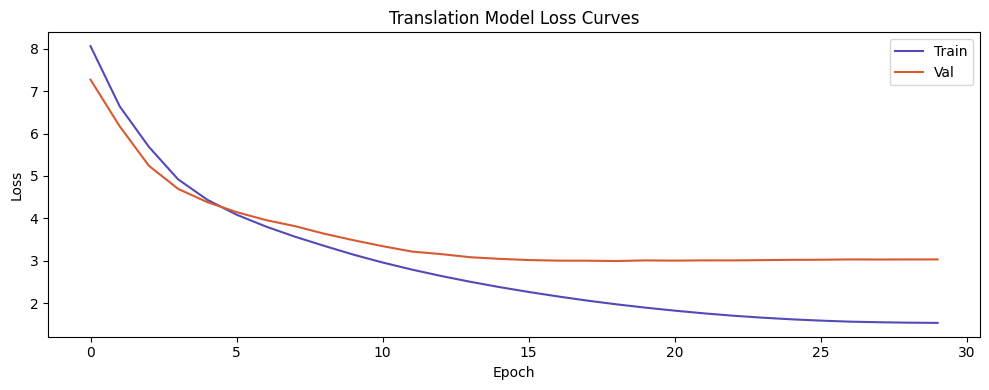

TRANSLATION EXAMPLES

📜 Gardiner: D21 D37 X1 S43 D46 X1 Y1 A2 Z3A N35 V28 Z7 M2 Z3A N12 Z1 M8J...
✅ Reference:  The matter of the Nebech plant (is) to be set (on) the first month of the season of Acheth (day) 17 (and) the ninth (nig
🤖 Predicted:  To be recited over 4 days of Shemu season: 4 days of Shemu season: 362 ⁇ .
----------------------------------------------------------------------

📜 Gardiner: R8 D21 D58 Z2 I9 O34 X1 Z2 D2 Z1 N35 V31 A1 R4 G40 U36 Z1 A1...
✅ Reference:  [Any] God who owns his food: They say to you: "[--- welcome to] peace, O authority figure, useful to {their}〈our〉 Ka!"
🤖 Predicted:  The gods are their names(?) for them, their Ka priest, their priest, who quickens their Ka with their Kamen.
----------------------------------------------------------------------

📜 Gardiner: D21 D36 G17 F51 O34...
✅ Reference:  Werde in ihr „Fleisch“ (d.h. ihre Vagina) gegeben.
🤖 Predicted:  Werde in werde gegeben gegeben gegeben gegeben gegeben gegeben gegeben.
----------------

In [13]:
# ── Cell 14: Test Translation Quality ─────────────────
import matplotlib.pyplot as plt

# ── Plot loss curves ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['train_loss'], label='Train', color='#534AB7')
ax.plot(history['val_loss'], label='Val', color='#D85A30')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Translation Model Loss Curves')
ax.legend()
plt.tight_layout()
plt.show()

# ── Load best model ───────────────────────────────────
model.load_state_dict(torch.load('/content/best_translator.pth'))
model.eval()

# ── Greedy decode function ────────────────────────────
def translate(src_text, model, max_len=100):
    model.eval()

    # Encode source
    src_tokens = src_text.split()[:200]
    src_ids = [src_token2idx.get(t, src_token2idx['<unk>']) for t in src_tokens]
    src_tensor = torch.tensor([src_ids]).to(device)

    # Start with <sos>
    tgt_ids = [1]  # <sos>

    for _ in range(max_len):
        tgt_tensor = torch.tensor([tgt_ids]).to(device)
        with torch.no_grad():
            output = model(src_tensor, tgt_tensor)
        next_token = output[0, -1].argmax().item()

        if next_token == 2:  # <eos>
            break
        tgt_ids.append(next_token)

    # Decode
    return tgt_sp.decode(tgt_ids[1:])  # skip <sos>

# ── Test on examples ──────────────────────────────────
print("=" * 70)
print("TRANSLATION EXAMPLES")
print("=" * 70)

# Test on val set
import random
random.seed(42)
test_indices = random.sample(range(len(test_pairs)), 10)

for idx in test_indices:
    pair = test_pairs[idx]
    codes = pair['source']
    reference = pair['target']
    prediction = translate(codes, model)

    print(f"\n📜 Gardiner: {codes[:60]}...")
    print(f"✅ Reference:  {reference[:120]}")
    print(f"🤖 Predicted:  {prediction[:120]}")
    print("-" * 70)

In [14]:
# ── Cell 15: Beam Search + BLEU Score ─────────────────
import torch.nn.functional as F

def translate_beam(src_text, model, beam_size=5, max_len=100):
    model.eval()

    # Encode source
    src_tokens = src_text.split()[:200]
    src_ids = [src_token2idx.get(t, src_token2idx['<unk>']) for t in src_tokens]
    src_tensor = torch.tensor([src_ids]).to(device)

    # Initialize beams: (score, token_ids)
    beams = [(0.0, [1])]  # start with <sos>
    completed = []

    for _ in range(max_len):
        candidates = []
        for score, tokens in beams:
            if tokens[-1] == 2:  # <eos>
                completed.append((score, tokens))
                continue

            tgt_tensor = torch.tensor([tokens]).to(device)
            with torch.no_grad():
                output = model(src_tensor, tgt_tensor)

            log_probs = F.log_softmax(output[0, -1], dim=-1)
            top_probs, top_ids = log_probs.topk(beam_size)

            for prob, idx in zip(top_probs, top_ids):
                # Repetition penalty
                token_id = idx.item()
                penalty = 0.0
                if len(tokens) >= 2 and token_id == tokens[-1]:
                    penalty = -2.0  # penalize immediate repetition
                if len(tokens) >= 3 and token_id == tokens[-1] == tokens[-2]:
                    penalty = -5.0  # heavily penalize triple repetition

                candidates.append((score + prob.item() + penalty, tokens + [token_id]))

        if not candidates:
            break

        # Keep top beams
        candidates.sort(key=lambda x: x[0] / max(len(x[1]), 1), reverse=True)  # length-normalized
        beams = candidates[:beam_size]

    # Return best
    all_results = completed + beams
    if not all_results:
        return ""
    all_results.sort(key=lambda x: x[0] / max(len(x[1]), 1), reverse=True)
    best_tokens = all_results[0][1]

    # Remove <sos> and <eos>
    clean = [t for t in best_tokens if t not in [0, 1, 2]]
    return tgt_sp.decode(clean)

# ── Compare greedy vs beam search ─────────────────────
print("=" * 70)
print("GREEDY vs BEAM SEARCH")
print("=" * 70)

import random
random.seed(42)
test_indices = random.sample(range(len(test_pairs)), 8)

for idx in test_indices:
    pair = test_pairs[idx]
    greedy_out = translate(pair['source'], model)
    beam_out = translate_beam(pair['source'], model, beam_size=5)

    print(f"\n📜 Gardiner:  {pair['source'][:55]}...")
    print(f"✅ Reference: {pair['target'][:100]}")
    print(f"🔹 Greedy:    {greedy_out[:100]}")
    print(f"🔷 Beam:      {beam_out[:100]}")
    print("-" * 70)

# ── BLEU Score ────────────────────────────────────────
from collections import Counter

def simple_bleu(reference, hypothesis, max_n=4):
    """Simple BLEU score implementation"""
    ref_tokens = reference.lower().split()
    hyp_tokens = hypothesis.lower().split()

    if len(hyp_tokens) == 0:
        return 0.0

    scores = []
    for n in range(1, max_n + 1):
        ref_ngrams = Counter([tuple(ref_tokens[i:i+n]) for i in range(len(ref_tokens)-n+1)])
        hyp_ngrams = Counter([tuple(hyp_tokens[i:i+n]) for i in range(len(hyp_tokens)-n+1)])

        matches = sum((hyp_ngrams & ref_ngrams).values())
        total = max(sum(hyp_ngrams.values()), 1)
        scores.append(matches / total)

    # Brevity penalty
    bp = min(1.0, len(hyp_tokens) / max(len(ref_tokens), 1))

    # Geometric mean
    if any(s == 0 for s in scores):
        return 0.0

    import math
    log_avg = sum(math.log(s) for s in scores) / len(scores)
    return bp * math.exp(log_avg)

# Calculate BLEU on test set
bleu_scores = []
for pair in test_pairs[:500]:  # first 500 for speed
    pred = translate_beam(pair['source'], model, beam_size=3)
    score = simple_bleu(pair['target'], pred)
    bleu_scores.append(score)

avg_bleu = sum(bleu_scores) / len(bleu_scores)
print(f"\n📊 Average BLEU Score (500 test samples): {avg_bleu:.4f} ({avg_bleu*100:.2f}%)")

GREEDY vs BEAM SEARCH

📜 Gardiner:  D21 D37 X1 S43 D46 X1 Y1 A2 Z3A N35 V28 Z7 M2 Z3A N12 Z...
✅ Reference: The matter of the Nebech plant (is) to be set (on) the first month of the season of Acheth (day) 17 
🔹 Greedy:    To be recited over 4 days of Shemu season: 4 days of Shemu season: 362 ⁇ .
🔷 Beam:      To be recited over 4 days, 3rd month of the season of Akhet season, day 1st month 4 of Akhet season 
----------------------------------------------------------------------

📜 Gardiner:  R8 D21 D58 Z2 I9 O34 X1 Z2 D2 Z1 N35 V31 A1 R4 G40 U36 ...
✅ Reference: [Any] God who owns his food: They say to you: "[--- welcome to] peace, O authority figure, useful to
🔹 Greedy:    The gods are their names(?) for them, their Ka priest, their priest, who quickens their Ka with thei
🔷 Beam:      "The gods who are upon their names, their Ka-priests, their Ka-priests, their Ka-priests, their Ka r
----------------------------------------------------------------------

📜 Gardiner:  D21 D36 G17 F51 O3

In [15]:
# ── Cell 16: Save everything ──────────────────────────
import shutil, os, json

# Save to Google Drive
save_dir = '/content/drive/MyDrive/Tourasna/hieroglyphics/translator'
os.makedirs(save_dir, exist_ok=True)

# Model weights
shutil.copy('/content/best_translator.pth', f'{save_dir}/best_translator.pth')

# BPE model
shutil.copy('/content/tgt_bpe.model', f'{save_dir}/tgt_bpe.model')
shutil.copy('/content/tgt_bpe.vocab', f'{save_dir}/tgt_bpe.vocab')

# Source vocab
with open(f'{save_dir}/src_vocab.json', 'w') as f:
    json.dump({'src_token2idx': src_token2idx, 'src_vocab': src_vocab}, f)

# Data splits
for name, data in [('train', train_pairs), ('val', val_pairs), ('test', test_pairs)]:
    shutil.copy(f'/content/{name}_pairs.json', f'{save_dir}/{name}_pairs.json')

# Metadata
metadata = {
    'model': 'HieroglyphTranslator (Transformer)',
    'd_model': 256, 'nhead': 8,
    'encoder_layers': 4, 'decoder_layers': 4,
    'src_vocab_size': len(src_vocab),
    'tgt_vocab_size': tgt_sp.get_piece_size(),
    'total_params': sum(p.numel() for p in model.parameters()),
    'best_val_loss': best_val_loss,
    'bleu_score': avg_bleu,
    'training_pairs': len(train_pairs),
    'dataset': 'BBAW Egyptian Corpus (35,497 parallel rows)',
    'tokenizer': 'SentencePiece BPE (8000)',
}
with open(f'{save_dir}/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("✅ All saved to Google Drive:")
print(f"   {save_dir}/")
for f in os.listdir(save_dir):
    size = os.path.getsize(f'{save_dir}/{f}')
    print(f"   ├── {f} ({size/1024:.0f} KB)")

✅ All saved to Google Drive:
   /content/drive/MyDrive/Tourasna/hieroglyphics/translator/
   ├── src_vocab.json (26 KB)
   ├── val_pairs.json (651 KB)
   ├── tgt_bpe.model (356 KB)
   ├── train_pairs.json (5579 KB)
   ├── best_translator.pth (46518 KB)
   ├── tgt_bpe.vocab (105 KB)
   ├── metadata.json (0 KB)
   ├── test_pairs.json (331 KB)
